# M2A1 - Detecção e Extração de Características

Na prática de hoje vamos utilizar [OpenCV](https://opencv.org/) para extrair características de imagens.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Extração de Caracteísticas
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [7]:
# TODO Atualize o path da imagem.
image = cv2.imread("./1.jpeg")

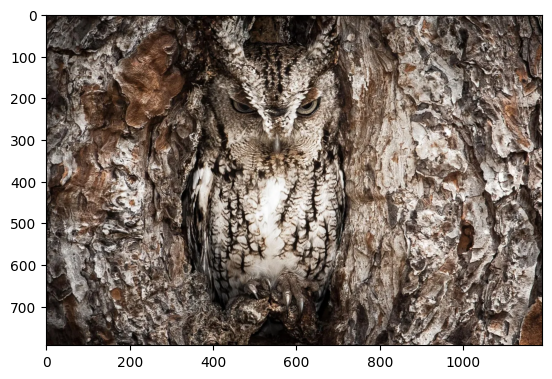

In [10]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Extração de Caracteísticas

Agora podemos criar o extrator e aplicar ele. Por exemplo o [SIFT](https://www.cs.ubc.ca/~lsigal/425_2024W1/ijcv04.pdf).

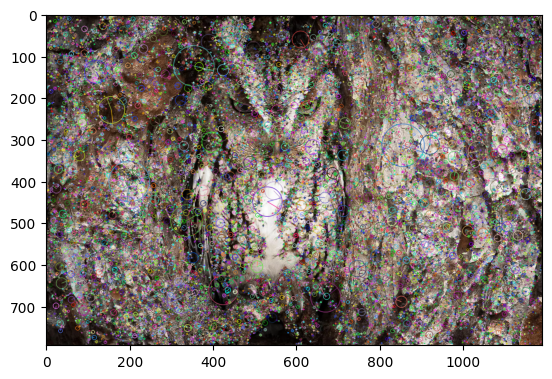

In [11]:
# Criando o detector do SIFT.
sift = cv2.SIFT_create()

# Detectando os keypoints e calculando os descritores.
keypoints, descriptors = sift.detectAndCompute(image, None)

# Visualizando os ketypoints.
image_kp = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(cv2.cvtColor(image_kp, cv2.COLOR_BGR2RGB))

OpenCV também implementa outros detectores como o [ORB](https://par.cse.nsysu.edu.tw/resource/paper/2016/161129/ORB-an%20efficient%20alternative%20to%20SIFT%20or%20SURF.pdf).

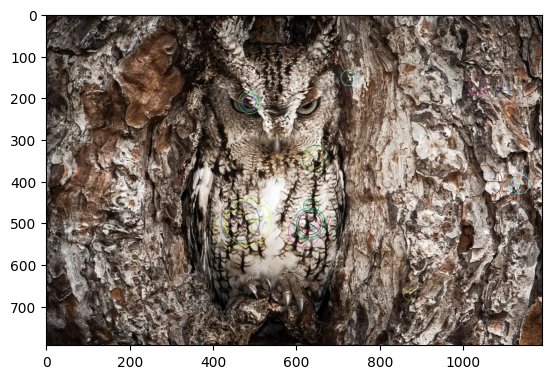

In [12]:
# Criando o detector do ORB.
orb = cv2.ORB_create(30)

# Detectando os keypoints e calculando os descritores.
keypoints, descriptors = orb.detectAndCompute(image, None)

# Visualizando os keypoints.
image_kp = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(cv2.cvtColor(image_kp, cv2.COLOR_BGR2RGB))

E assim terminamos a prática de hoje.

## Próximos Passos e Referências

Nas próximas práticas iremos utilizar essas características para encontrar correspondências em imagens.

Uma lista não exaustiva de referências segue:

- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opicional)

- [ ] Leia a imagem e rode todos os comandos.
- [ ] Existe alguma forma de melhorar os resutlados do SIFT?
- [ ] Existem outros detectores já implementados pela OpenCV?

### Melhorar resultados SIFT

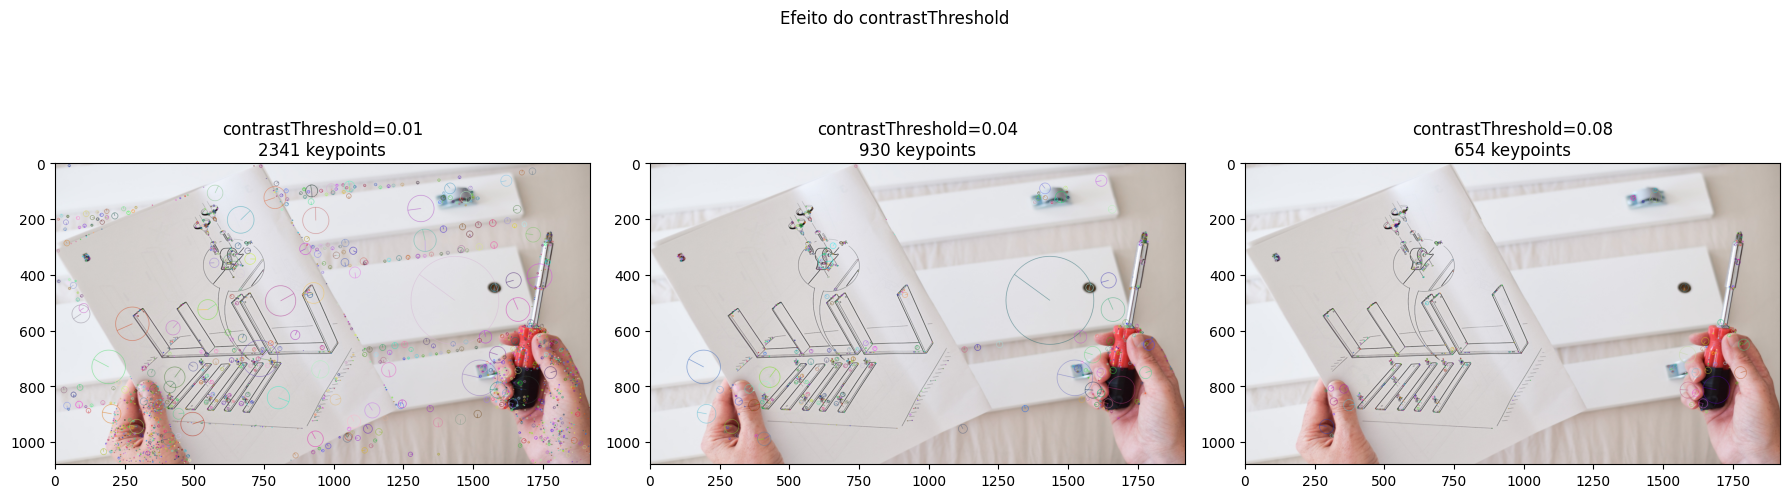

In [8]:
thresholds = [0.01, 0.04, 0.08]

fig, axes = plt.subplots(1, len(thresholds), figsize=(18, 6))

for ax, ct in zip(axes, thresholds):
    sift_ct = cv2.SIFT_create(contrastThreshold=ct)
    kp, _ = sift_ct.detectAndCompute(image, None)
    img_kp = cv2.drawKeypoints(
        image, kp, None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    ax.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
    ax.set_title(f"contrastThreshold={ct}\n{len(kp)} keypoints")

plt.suptitle("Efeito do contrastThreshold")
plt.tight_layout()

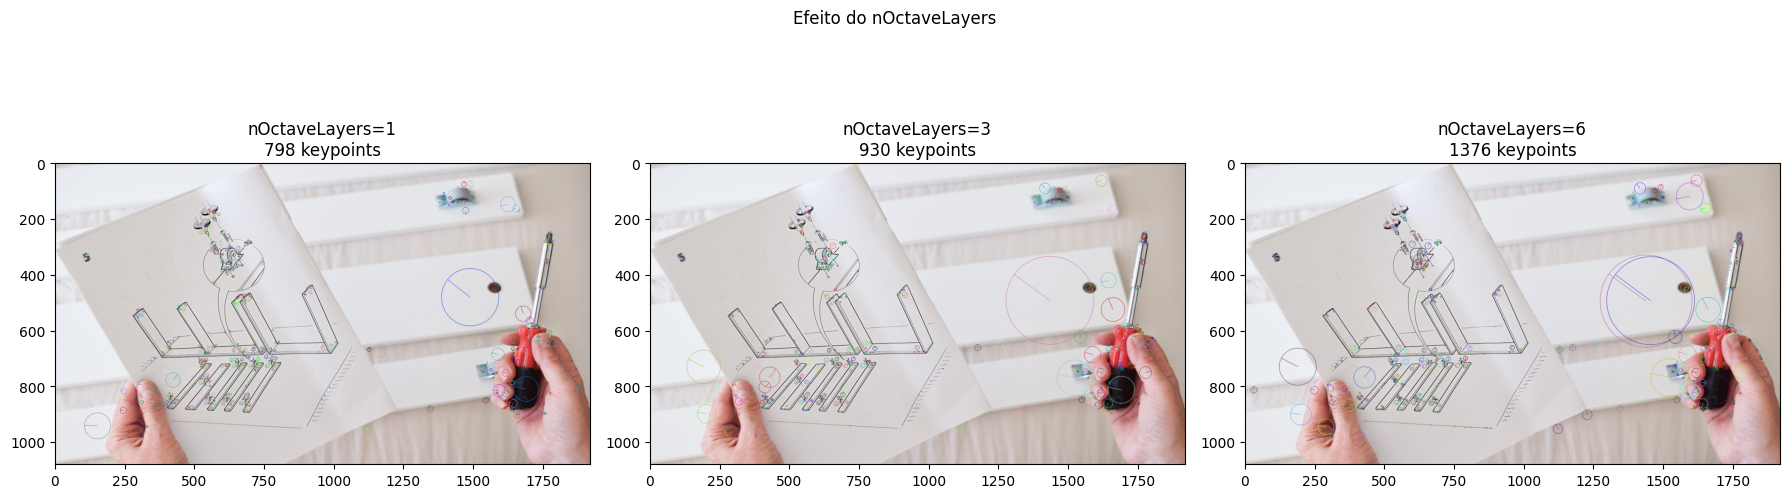

In [9]:
octave_layers = [1, 3, 6]

fig, axes = plt.subplots(1, len(octave_layers), figsize=(18, 6))

for ax, n in zip(axes, octave_layers):
    sift_n = cv2.SIFT_create(nOctaveLayers=n)
    kp, _ = sift_n.detectAndCompute(image, None)
    img_kp = cv2.drawKeypoints(
        image, kp, None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    ax.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
    ax.set_title(f"nOctaveLayers={n}\n{len(kp)} keypoints")

plt.suptitle("Efeito do nOctaveLayers")
plt.tight_layout()

### Outros detectores

AKAZE — 1493 keypoints


Text(0.5, 1.0, 'AKAZE — 1493 keypoints')

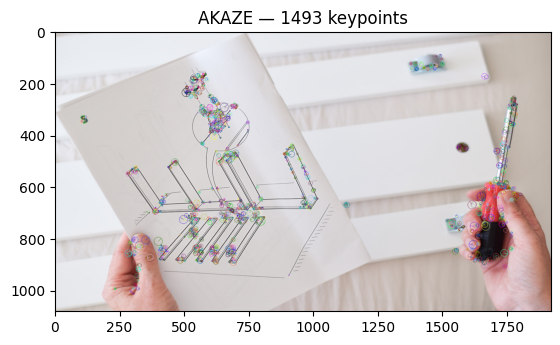

In [10]:
akaze = cv2.AKAZE_create()
kp_akaze, desc_akaze = akaze.detectAndCompute(image, None)

img_akaze = cv2.drawKeypoints(
    image, kp_akaze, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

print(f"AKAZE — {len(kp_akaze)} keypoints")
plt.imshow(cv2.cvtColor(img_akaze, cv2.COLOR_BGR2RGB))
plt.title(f"AKAZE — {len(kp_akaze)} keypoints")

BRISK — 5528 keypoints


Text(0.5, 1.0, 'BRISK — 5528 keypoints')

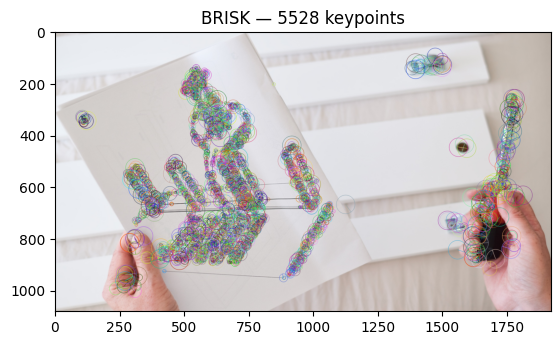

In [11]:
brisk = cv2.BRISK_create()
kp_brisk, desc_brisk = brisk.detectAndCompute(image, None)

img_brisk = cv2.drawKeypoints(
    image, kp_brisk, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

print(f"BRISK — {len(kp_brisk)} keypoints")
plt.imshow(cv2.cvtColor(img_brisk, cv2.COLOR_BGR2RGB))
plt.title(f"BRISK — {len(kp_brisk)} keypoints")

FAST — 4013 keypoints


Text(0.5, 1.0, 'FAST — 4013 keypoints (sem descriptor)')

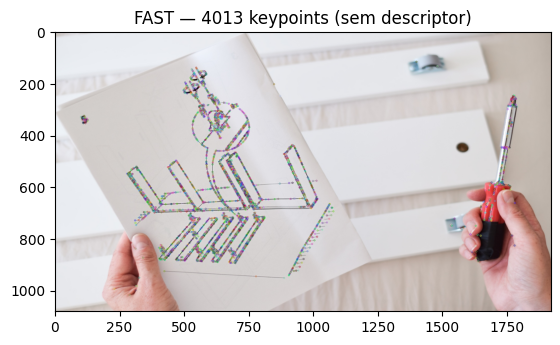

In [12]:
fast = cv2.FastFeatureDetector_create(threshold=20)
kp_fast = fast.detect(image, None)

img_fast = cv2.drawKeypoints(image, kp_fast, None)

print(f"FAST — {len(kp_fast)} keypoints")
plt.imshow(cv2.cvtColor(img_fast, cv2.COLOR_BGR2RGB))
plt.title(f"FAST — {len(kp_fast)} keypoints (sem descriptor)")